
# Spatial Variation in Childhood Obesity Across London Boroughs
### A borough-level comparison of Reception and Year 6 obesity prevalence



## Preparation

- Github link:
- Number of words:1325
- Runtime: *0.15hours(colab)*
- Coding environment: *Python 3*
- License: this notebook is made available under the [Creative Commons Attribution 4.0 license](https://creativecommons.org/licenses/by/4.0/).
- Additional library:
    - **openpyxl**: used to read the multi-sheet Excel workbook



## Table of contents

1. [Introduction](#Introduction)
2. [Research questions](#Research-questions)
3. [Data](#Data)
4. [Methodology](#Methodology)
5. [Results and discussion](#Results-and-discussion)
6. [Conclusion](#Conclusion)
7. [References](#References)



## Introduction

[[ go back to the top ]](#Table-of-contents)

### 1.1 Background

Childhood obesity is an important public health problem, which directly damages children's physical and mental health and increases their risk of chronic diseases in the future (World Health Organization, 2025). England conducts routine weight monitoring of Reception and Year 6 children through the National Child Measurement Programme to grasp relevant trends and health inequalities (NHS Digital, 2023). The latest data shows that the obesity rate of Year 6 children is significantly higher than that of Reception children, and health inequalities caused by place and deprivation is still very prominent (Office for Health Improvement and Disparities, 2023).

### 1.2 Spatial context

From the perspective of spatial data research, childhood obesity is not only a health problem but also reflects the uneven development between regions. By comparing the administrative regions of London, we can see the difference in the obesity rate of children in different regions, and whether these differences vary in different grades.
The research data are also very obvious: the obesity rate in London districts is very different. The obesity rate of children in Year 6 has always been higher than that in Reception, and the obesity rate gap between the two grades also varies by district.
### 1.3 Aim

This study aims to describe the spatial differences in the prevalence of obesity among children in various administrative regions of London, compare the obesity distribution characteristics of Reception and Year 6 children, and analyze whether the degree of poverty at the administrative level is related to the higher prevalence of obesity or the greater difference in school age. The research takes descriptive analysis and spatial analysis as the core, and uses poverty and related models as auxiliary explanation tools.


## Research questions

[[ go back to the top ]](#Table-of-contents)

### 2.1 Main research question

What are the spatial differences in the prevalence of childhood obesity in London's administrative regions? What is the difference between these distribution patterns between Reception and Year 6?
### 2.2 Sub-questions
1.Which districts in London have the highest and lowest rate of child obesity? Is this situation stable in the long run?

2.In which districts is there the biggest obesity rate gap between children in Year 6 and Reception?

3.Will the degree of regional poverty make the obesity rate higher, or the gap between grades larger?

4.After analyzing with the tree model, how much impact do the factors of grade, region, year and poverty have on the obesity rate?



## Data

[[ go back to the top ]](#Table-of-contents)

### 3.1 Data source and study area

The main dataset of this study is a childhood obesity workbook at borough level derived from NCMP (NHS Digital, 2023).
data link: https://data.london.gov.uk/dataset/prevalence-childhood-obesity-borough

### 3.2 Data cleaning and restructuring

For the convenience of comparison, only the data from 2007/08 to 2018/19 is retained.
Data for 2006/07 because the geographical boundaries are inconsistent, and data for 2019/20 because missing values exist, have been deleted. After that, the multi-row headers were reorganized and only the obesity-related variables was extracted. Finally, the data is sorted into a long table arranged by borough-year-school-stage, and each line corresponds to a London borough, a year and a school stage.
### 3.3 Analytical variables

The dependent variable of this study is obesity prevalence.The core comparison variable is school_stage, in which boroughs are the spatial analysis units, and year_start is used to describe temporal changes.The study retains confidence intervals for result interpretation, and n_measured is used only for descriptive purposes.The study adds a supplementary variable, imd_score, to reflect the socio-economic background at the borough level.As the data comes from the 2019 deprivation file（data link: https://data.london.gov.uk/dataset/indices-of-deprivation-2l15g/）, it is regarded as a time-invariant contextual indicator rather than a year-specific variable.


| Variable | Type | Description | Notes |
|---|---|---|---|
| `borough` | Categorical | Name of London borough | Spatial unit of analysis |
| `year_label` | Categorical | Academic year label (e.g. `2018-19`) | Used for filtering and display |
| `year_start` | Numeric | First year of the academic year (e.g. `2018`) | Used as an ordered time variable |
| `school_stage` | Categorical | `Reception` or `Year 6` | Main non-spatial comparison variable |
| `obesity_prevalence` | Numeric | Obesity prevalence (%) | Main dependent variable |
| `obesity_ci_lower` | Numeric | Lower confidence interval | Retained for interpretation |
| `obesity_ci_upper` | Numeric | Upper confidence interval | Retained for interpretation |
| `n_measured` | Numeric | Number of children measured | Descriptive only; not the main analytical focus |



## Methodology

[[ go back to the top ]](#Table-of-contents)

### 4.1 Analytical workflow

This analysis conducts spatial analysis of London's boroughs. First, it cleans and reshapes the data, then uses descriptive statistics and visualization to compare obesity data across different boroughs, school stages and years.
Through spatial visualization, the obesity prevalence distribution in the 2018/19 academic year is presented, differences in obesity rates between school stages are analyzed, and poverty analysis and tree-based models are used to aid interpretation.

### 4.2 Supplementary deprivation and modelling methods
The study uses the IMD deprivation index across London boroughs to analyze the relationship between poverty, obesity prevalence, and school-stage obesity gaps, with tests using scatter plots and correlation coefficients.
At the same time, regression tree and random forest models are constructed, with obesity prevalence as the dependent variable and borough, school_stage, year, and IMD score as independent variables. The model is evaluated using R² and RMSE, and results are interpreted using permutation importance.


In [3]:
# =========================
# Imports
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Optional / used later
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance

# Display options
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

In [2]:

# =========================
# Data import and cleaning
# =========================

file_path = "childhood-obesity-borough.xlsx"

LONDON_BOROUGHS = [
    'Barking and Dagenham', 'Barnet', 'Bexley', 'Brent', 'Bromley', 'Camden',
    'Croydon', 'Ealing', 'Enfield', 'Greenwich', 'Hammersmith and Fulham',
    'Haringey', 'Harrow', 'Havering', 'Hillingdon', 'Hounslow', 'Islington',
    'Kensington and Chelsea', 'Kingston upon Thames', 'Lambeth', 'Lewisham',
    'Merton', 'Newham', 'Redbridge', 'Richmond upon Thames', 'Southwark',
    'Sutton', 'Tower Hamlets', 'Waltham Forest', 'Wandsworth', 'Westminster'
]

YEARS = [f"{y}-{str(y+1)[-2:]}" for y in range(2007, 2019)]

def extract_obesity_sheet(file_path, sheet_name):
    raw = pd.read_excel(file_path, sheet_name=sheet_name, header=None)

    header_rows = raw.iloc[:3].copy().ffill(axis=1)

    col_names = []
    for j in range(raw.shape[1]):
        parts = [
            str(header_rows.iloc[i, j]).strip()
            for i in range(3)
            if pd.notna(header_rows.iloc[i, j])
        ]
        col_names.append(" | ".join(parts))

    df = raw.iloc[4:].copy()
    df.columns = col_names

    df = df.rename(columns={
        col_names[0]: "code",
        col_names[1]: "borough"
    })

    df = df[df["borough"].isin(LONDON_BOROUGHS)].copy()

    obesity_prefix = None
    for c in df.columns:
        c_low = c.lower()
        if ("obese" in c_low) and ("prevalence" in c_low) and ("severely obese" not in c_low):
            obesity_prefix = c.split(" | ")[0]
            break

    if obesity_prefix is None:
        raise ValueError(f"Could not find obesity columns in sheet {sheet_name}")

    def pick_col(stage, keywords):
        for c in df.columns:
            c_low = c.lower()
            if c.startswith(obesity_prefix) and stage.lower() in c_low and all(k in c_low for k in keywords):
                return c
        raise ValueError(f"Missing column for {stage} / {keywords} in sheet {sheet_name}")

    rec_prev = pick_col("Reception", ["prevalence"])
    y6_prev = pick_col("Year 6", ["prevalence"])

    has_lower_upper = any(
        c.startswith(obesity_prefix) and "lower confidence interval" in c.lower()
        for c in df.columns
    )

    measured_cols = [c for c in df.columns if "number of children measured" in c.lower()]
    rec_n = [c for c in measured_cols if "reception" in c.lower()][0]
    y6_n = [c for c in measured_cols if "year 6" in c.lower()][0]

    out = pd.DataFrame({
        "borough": df["borough"],
        "year_label": sheet_name,
        "year_start": int(sheet_name[:4]),
        "reception_obesity_prevalence": pd.to_numeric(df[rec_prev], errors="coerce"),
        "year6_obesity_prevalence": pd.to_numeric(df[y6_prev], errors="coerce"),
        "reception_n_measured": pd.to_numeric(df[rec_n], errors="coerce"),
        "year6_n_measured": pd.to_numeric(df[y6_n], errors="coerce"),
    })

    if has_lower_upper:
        rec_low = pick_col("Reception", ["lower confidence interval"])
        rec_up  = pick_col("Reception", ["upper confidence interval"])
        y6_low  = pick_col("Year 6", ["lower confidence interval"])
        y6_up   = pick_col("Year 6", ["upper confidence interval"])

        out["reception_ci_lower"] = pd.to_numeric(df[rec_low], errors="coerce")
        out["reception_ci_upper"] = pd.to_numeric(df[rec_up], errors="coerce")
        out["year6_ci_lower"]     = pd.to_numeric(df[y6_low], errors="coerce")
        out["year6_ci_upper"]     = pd.to_numeric(df[y6_up], errors="coerce")
    else:
        rec_margin = pick_col("Reception", ["confidence interval"])
        y6_margin  = pick_col("Year 6", ["confidence interval"])

        rec_margin_num = pd.to_numeric(df[rec_margin], errors="coerce")
        y6_margin_num  = pd.to_numeric(df[y6_margin], errors="coerce")

        out["reception_ci_lower"] = out["reception_obesity_prevalence"] - rec_margin_num
        out["reception_ci_upper"] = out["reception_obesity_prevalence"] + rec_margin_num
        out["year6_ci_lower"]     = out["year6_obesity_prevalence"] - y6_margin_num
        out["year6_ci_upper"]     = out["year6_obesity_prevalence"] + y6_margin_num

    return out

wide_parts = [extract_obesity_sheet(file_path, year) for year in YEARS]
obesity_wide = pd.concat(wide_parts, ignore_index=True)

reception_df = (
    obesity_wide[
        ["borough", "year_label", "year_start",
         "reception_obesity_prevalence", "reception_ci_lower", "reception_ci_upper", "reception_n_measured"]
    ]
    .rename(columns={
        "reception_obesity_prevalence": "obesity_prevalence",
        "reception_ci_lower": "obesity_ci_lower",
        "reception_ci_upper": "obesity_ci_upper",
        "reception_n_measured": "n_measured"
    })
    .assign(school_stage="Reception")
)

year6_df = (
    obesity_wide[
        ["borough", "year_label", "year_start",
         "year6_obesity_prevalence", "year6_ci_lower", "year6_ci_upper", "year6_n_measured"]
    ]
    .rename(columns={
        "year6_obesity_prevalence": "obesity_prevalence",
        "year6_ci_lower": "obesity_ci_lower",
        "year6_ci_upper": "obesity_ci_upper",
        "year6_n_measured": "n_measured"
    })
    .assign(school_stage="Year 6")
)

obesity_model_long = pd.concat([reception_df, year6_df], ignore_index=True)

obesity_model_long = obesity_model_long[
    ["borough", "year_label", "year_start", "school_stage",
     "obesity_prevalence", "obesity_ci_lower", "obesity_ci_upper", "n_measured"]
].copy()

obesity_model_long["borough"] = obesity_model_long["borough"].astype(str).str.strip()
obesity_model_long["year_label"] = obesity_model_long["year_label"].astype("category")
obesity_model_long["school_stage"] = pd.Categorical(
    obesity_model_long["school_stage"],
    categories=["Reception", "Year 6"],
    ordered=True
)

obesity_map_2018 = obesity_model_long[obesity_model_long["year_label"] == "2018-19"].copy()

print("obesity_wide shape:", obesity_wide.shape)
print("obesity_model_long shape:", obesity_model_long.shape)
print("obesity_map_2018 shape:", obesity_map_2018.shape)

display(obesity_model_long.head())

obesity_model_long.to_csv("obesity_model_long.csv", index=False)
obesity_map_2018.to_csv("obesity_map_2018.csv", index=False)


obesity_wide shape: (372, 11)
obesity_model_long shape: (744, 8)
obesity_map_2018 shape: (62, 8)


,borough,year_label,year_start,school_stage,obesity_prevalence,obesity_ci_lower,obesity_ci_upper,n_measured
0,Barking and Dagenham,2007-08,2007,Reception,13.492823,12.027760,14.957886,2090
1,Barnet,2007-08,2007,Reception,8.846283,7.825364,9.867202,2973
2,Bexley,2007-08,2007,Reception,9.604520,8.351135,10.857904,2124
3,Brent,2007-08,2007,Reception,10.639021,9.524661,11.753381,2942
4,Bromley,2007-08,2007,Reception,7.306684,6.383238,8.230130,3052


In [4]:

# =========================
# Build borough-level deprivation data from ward-level file
# =========================

dep_file = "London wards id2019 summary measures.xlsx"
dep_sheet = "wards_id_summary"

dep_raw = pd.read_excel(dep_file, sheet_name=dep_sheet)

dep_raw = dep_raw[["Borough", "IMD average score"]].copy()
dep_raw["Borough"] = dep_raw["Borough"].astype(str).str.strip()

borough_dep = (
    dep_raw.groupby("Borough", as_index=False)["IMD average score"]
    .mean()
    .rename(columns={
        "Borough": "borough",
        "IMD average score": "imd_score"
    })
)

borough_dep["borough"] = borough_dep["borough"].astype(str).str.strip()

# Merge into main table
obesity_model_long_enhanced = obesity_model_long.merge(
    borough_dep,
    on="borough",
    how="left"
)

missing_boroughs = (
    obesity_model_long_enhanced.loc[
        obesity_model_long_enhanced["imd_score"].isna(), ["borough"]
    ]
    .drop_duplicates()
    .sort_values("borough")
)

print("Missing deprivation values:", obesity_model_long_enhanced["imd_score"].isna().sum())
if len(missing_boroughs) > 0:
    display(missing_boroughs)

display(borough_dep.head())
display(obesity_model_long_enhanced.head())

obesity_model_long_enhanced.to_csv("obesity_model_long_enhanced.csv", index=False)
borough_dep.to_csv("borough_deprivation_from_ward_imd2019.csv", index=False)


Missing deprivation values: 0


,borough,imd_score
0,Barking and Dagenham,32.768253
1,Barnet,15.821108
2,Bexley,16.473071
3,Brent,25.095808
4,Bromley,14.041901


,borough,year_label,year_start,school_stage,obesity_prevalence,obesity_ci_lower,obesity_ci_upper,n_measured,imd_score
0,Barking and Dagenham,2007-08,2007,Reception,13.492823,12.027760,14.957886,2090,32.768253
1,Barnet,2007-08,2007,Reception,8.846283,7.825364,9.867202,2973,15.821108
2,Bexley,2007-08,2007,Reception,9.604520,8.351135,10.857904,2124,16.473071
3,Brent,2007-08,2007,Reception,10.639021,9.524661,11.753381,2942,25.095808
4,Bromley,2007-08,2007,Reception,7.306684,6.383238,8.230130,3052,14.041901


In [5]:

# =========================
# Descriptive summary
# =========================

summary_by_stage = (
    obesity_model_long.groupby("school_stage", observed=False)["obesity_prevalence"]
    .agg(["count", "mean", "median", "min", "max", "std"])
    .round(2)
)

summary_by_year_stage = (
    obesity_model_long.groupby(["year_label", "school_stage"], observed=False)["obesity_prevalence"]
    .mean()
    .reset_index()
)

summary_by_borough_stage = (
    obesity_model_long.groupby(["borough", "school_stage"], observed=False)["obesity_prevalence"]
    .mean()
    .reset_index()
)

display(summary_by_stage)
display(summary_by_year_stage.head())
display(summary_by_borough_stage.head())


,count,mean,median,min,max,std
school_stage,,,,,,
Reception,372,10.37,10.41,4.59,14.74,2.1
Year 6,372,22.06,22.66,10.67,30.03,3.5


,year_label,school_stage,obesity_prevalence
0,2007-08,Reception,10.683106
1,2007-08,Year 6,21.378639
2,2008-09,Reception,11.008643
3,2008-09,Year 6,21.023052
4,2009-10,Reception,11.252451


,borough,school_stage,obesity_prevalence
0,Barking and Dagenham,Reception,13.465471
1,Barking and Dagenham,Year 6,26.364744
2,Barnet,Reception,9.259206
3,Barnet,Year 6,19.036468
4,Bexley,Reception,10.967543


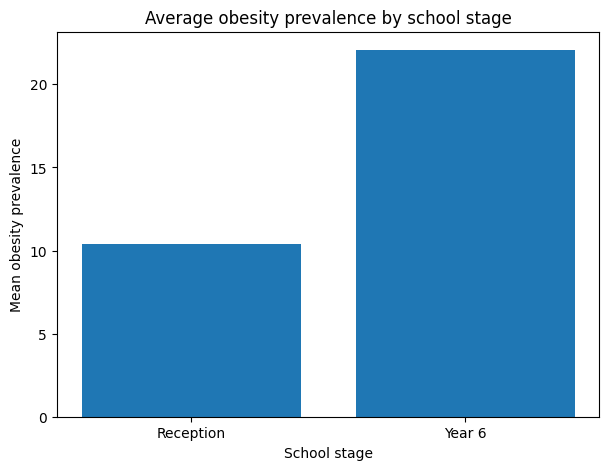

school_stage,borough,gap_y6_minus_reception
0,Westminster,13.865640
1,Southwark,13.550022
2,Tower Hamlets,13.461276
3,Newham,13.299456
4,Lewisham,13.167725
5,Lambeth,12.965401
6,Barking and Dagenham,12.899273
7,Waltham Forest,12.687521
8,Hammersmith and Fulham,12.563859
9,Brent,12.424492


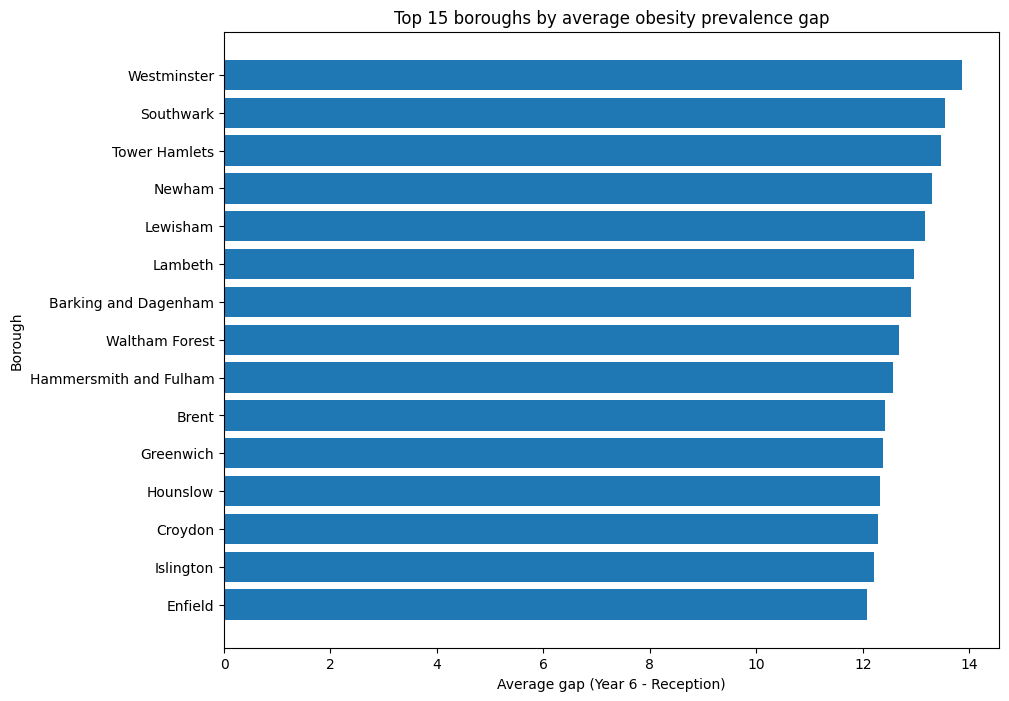

In [6]:

# =========================
# Compare Reception and Year 6
# =========================

stage_means = (
    obesity_model_long.groupby("school_stage", observed=False)["obesity_prevalence"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(7, 5))
plt.bar(stage_means["school_stage"], stage_means["obesity_prevalence"])
plt.xlabel("School stage")
plt.ylabel("Mean obesity prevalence")
plt.title("Average obesity prevalence by school stage")
plt.show()

borough_stage_pivot = (
    summary_by_borough_stage.pivot(index="borough", columns="school_stage", values="obesity_prevalence")
    .dropna()
)
borough_stage_pivot["gap_y6_minus_reception"] = borough_stage_pivot["Year 6"] - borough_stage_pivot["Reception"]

gap_rank_all_years = (
    borough_stage_pivot[["gap_y6_minus_reception"]]
    .sort_values("gap_y6_minus_reception", ascending=False)
    .reset_index()
)

display(gap_rank_all_years.head(10))

plt.figure(figsize=(10, 8))
top_gap = gap_rank_all_years.head(15).sort_values("gap_y6_minus_reception", ascending=True)
plt.barh(top_gap["borough"], top_gap["gap_y6_minus_reception"])
plt.xlabel("Average gap (Year 6 - Reception)")
plt.ylabel("Borough")
plt.title("Top 15 boroughs by average obesity prevalence gap")
plt.show()


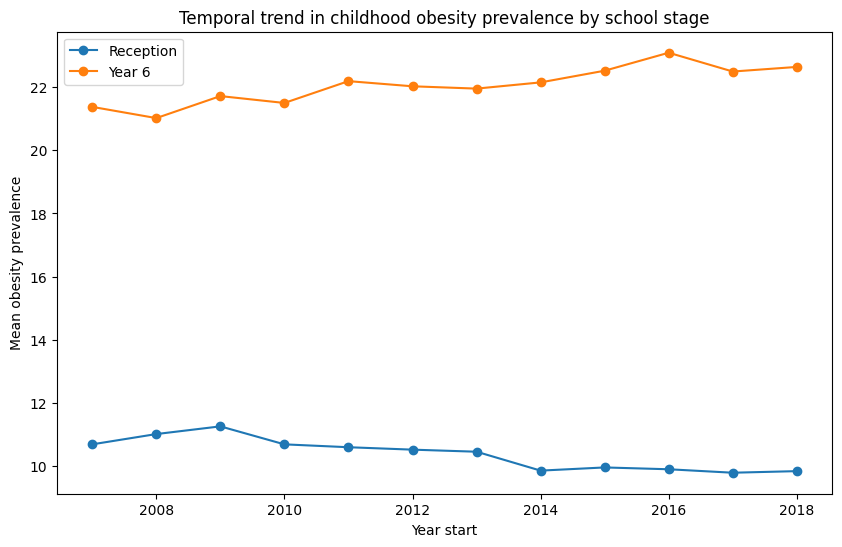

In [7]:

# =========================
# Temporal trends by school stage
# =========================

trend_df = (
    obesity_model_long.groupby(["year_start", "school_stage"], observed=False)["obesity_prevalence"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))
for stage in ["Reception", "Year 6"]:
    stage_data = trend_df[trend_df["school_stage"] == stage]
    plt.plot(stage_data["year_start"], stage_data["obesity_prevalence"], marker="o", label=stage)

plt.xlabel("Year start")
plt.ylabel("Mean obesity prevalence")
plt.title("Temporal trend in childhood obesity prevalence by school stage")
plt.legend()
plt.show()


In [8]:

# =========================
# London borough choropleth maps
# =========================

import geopandas as gpd

# Public GeoJSON source
geojson_url = "https://raw.githubusercontent.com/radoi90/housequest-data/master/london_boroughs.geojson"
borough_gdf = gpd.read_file(geojson_url)

# Find borough name column
name_col = None
for candidate in ["name", "Name", "NAME", "borough", "Borough"]:
    if candidate in borough_gdf.columns:
        name_col = candidate
        break

if name_col is None:
    raise ValueError("Could not find borough name column in the GeoJSON file.")

borough_gdf = borough_gdf.rename(columns={name_col: "borough"})
borough_gdf["borough"] = borough_gdf["borough"].astype(str).str.strip()

# Keep only boroughs in the obesity dataset
valid_boroughs = set(obesity_map_2018["borough"].unique())
borough_gdf = borough_gdf[borough_gdf["borough"].isin(valid_boroughs)].copy()

map_df = obesity_map_2018.copy()
map_df["obesity_prevalence"] = pd.to_numeric(map_df["obesity_prevalence"], errors="coerce")

reception_map = map_df[map_df["school_stage"] == "Reception"][["borough", "obesity_prevalence"]].copy()
year6_map = map_df[map_df["school_stage"] == "Year 6"][["borough", "obesity_prevalence"]].copy()

reception_geo = borough_gdf.merge(reception_map, on="borough", how="left")
year6_geo = borough_gdf.merge(year6_map, on="borough", how="left")

gap_df_2018 = (
    map_df.pivot(index="borough", columns="school_stage", values="obesity_prevalence")
    .reset_index()
    .dropna()
)
gap_df_2018["gap_y6_minus_reception"] = gap_df_2018["Year 6"] - gap_df_2018["Reception"]

gap_geo = borough_gdf.merge(
    gap_df_2018[["borough", "gap_y6_minus_reception"]],
    on="borough",
    how="left"
)

print("Reception map rows:", reception_geo.shape[0])
print("Year 6 map rows:", year6_geo.shape[0])
print("Gap map rows:", gap_geo.shape[0])


Reception map rows: 31
Year 6 map rows: 31
Gap map rows: 31


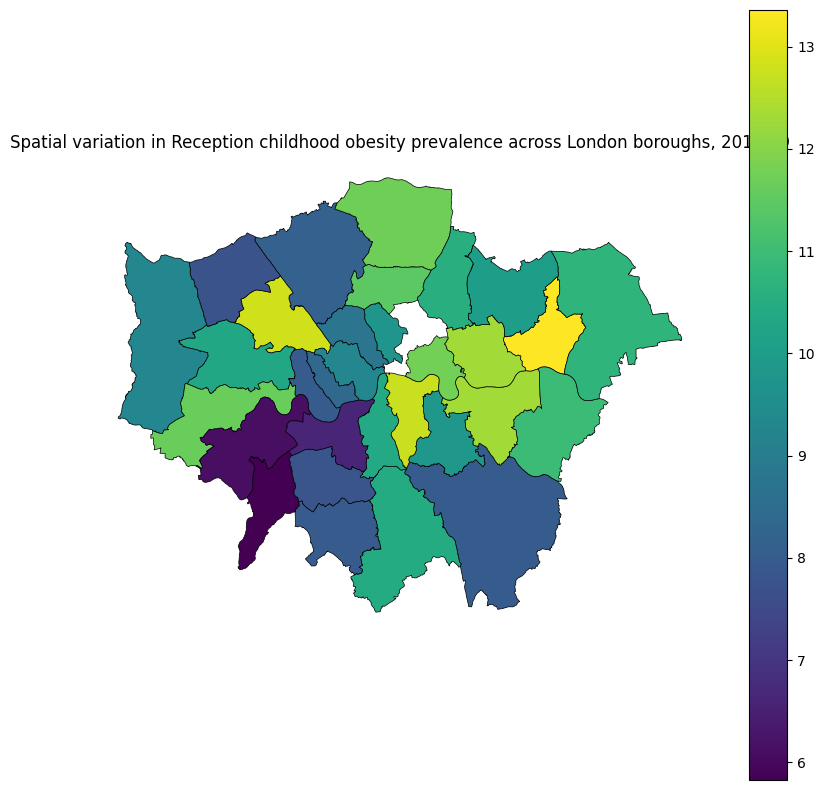

In [9]:

# Plot: Reception obesity prevalence map
fig, ax = plt.subplots(figsize=(10, 10))
reception_geo.plot(
    column="obesity_prevalence",
    ax=ax,
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    missing_kwds={"color": "lightgrey", "label": "Missing"}
)
ax.set_title("Spatial variation in Reception childhood obesity prevalence across London boroughs, 2018/19")
ax.axis("off")
plt.show()


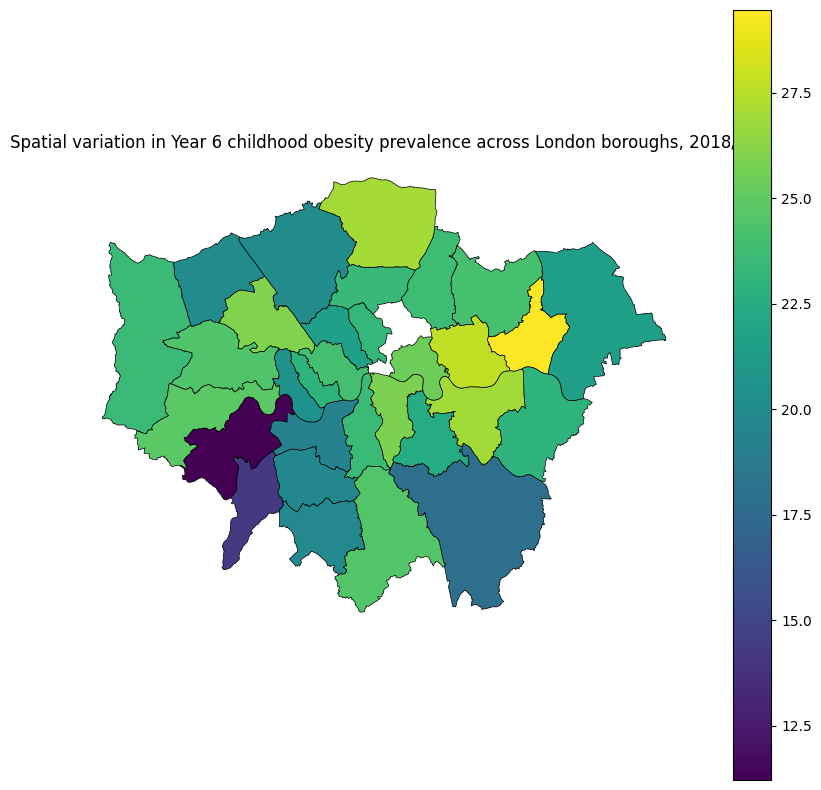

In [10]:

# Plot: Year 6 obesity prevalence map
fig, ax = plt.subplots(figsize=(10, 10))
year6_geo.plot(
    column="obesity_prevalence",
    ax=ax,
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    missing_kwds={"color": "lightgrey", "label": "Missing"}
)
ax.set_title("Spatial variation in Year 6 childhood obesity prevalence across London boroughs, 2018/19")
ax.axis("off")
plt.show()


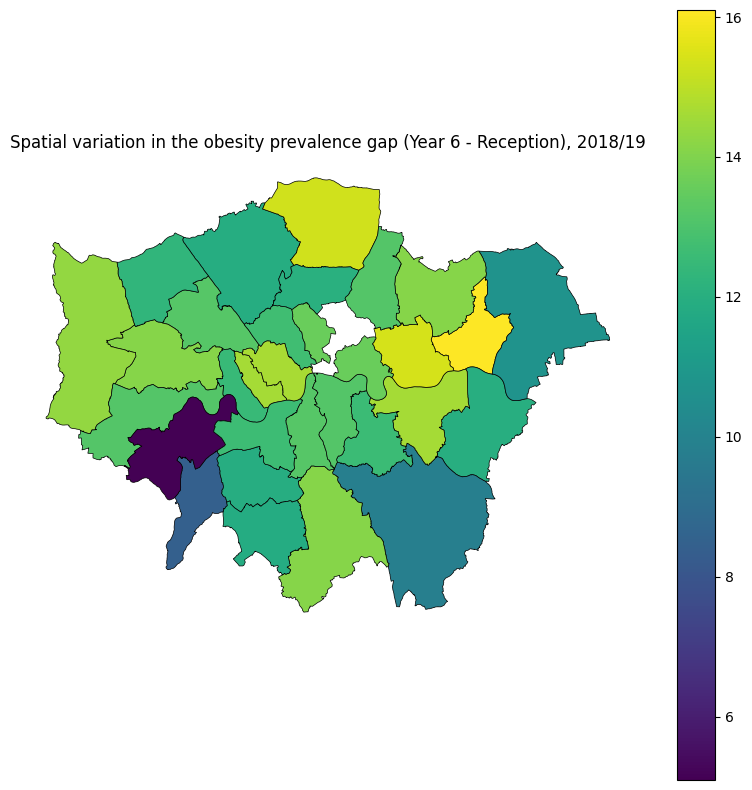

In [11]:

# Plot: Year 6 - Reception gap map
fig, ax = plt.subplots(figsize=(10, 10))
gap_geo.plot(
    column="gap_y6_minus_reception",
    ax=ax,
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    missing_kwds={"color": "lightgrey", "label": "Missing"}
)
ax.set_title("Spatial variation in the obesity prevalence gap (Year 6 - Reception), 2018/19")
ax.axis("off")
plt.show()


school_stage,borough,gap_y6_minus_reception
0,Barking and Dagenham,16.100413
22,Newham,15.410073
8,Enfield,15.314136
30,Westminster,14.679282
17,Kensington and Chelsea,14.630757
9,Greenwich,14.630468
14,Hillingdon,14.314172
23,Redbridge,14.109015
7,Ealing,14.103615
6,Croydon,14.085560


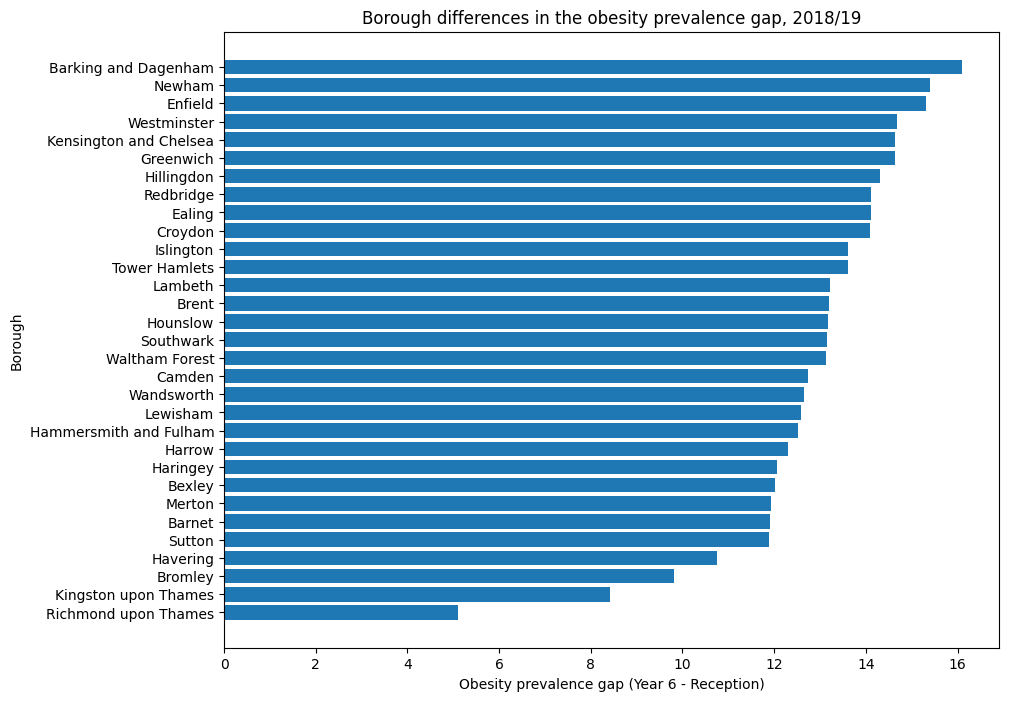

In [12]:

# =========================
# Gap ranking for 2018/19
# =========================

gap_rank_2018 = gap_df_2018[["borough", "gap_y6_minus_reception"]].sort_values(
    "gap_y6_minus_reception", ascending=False
)

display(gap_rank_2018.head(10))

plt.figure(figsize=(10, 8))
gap_rank_plot = gap_rank_2018.sort_values("gap_y6_minus_reception", ascending=True)
plt.barh(gap_rank_plot["borough"], gap_rank_plot["gap_y6_minus_reception"])
plt.xlabel("Obesity prevalence gap (Year 6 - Reception)")
plt.ylabel("Borough")
plt.title("Borough differences in the obesity prevalence gap, 2018/19")
plt.show()


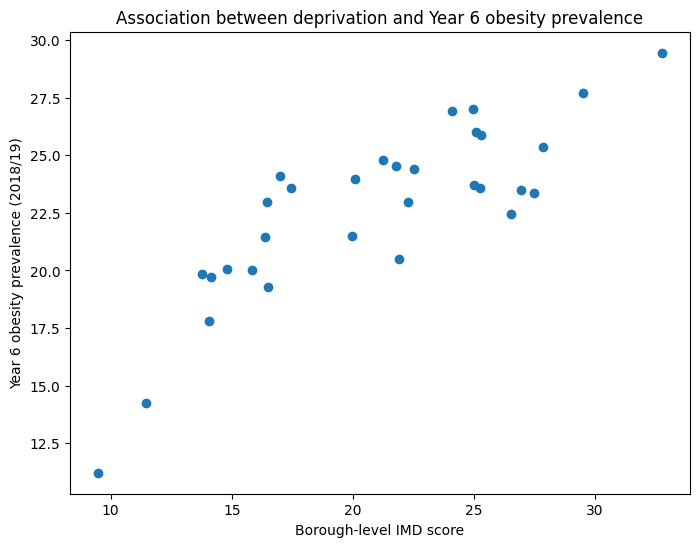

Correlation: IMD score vs Year 6 obesity prevalence


,imd_score,obesity_prevalence
imd_score,1.000000,0.832241
obesity_prevalence,0.832241,1.000000


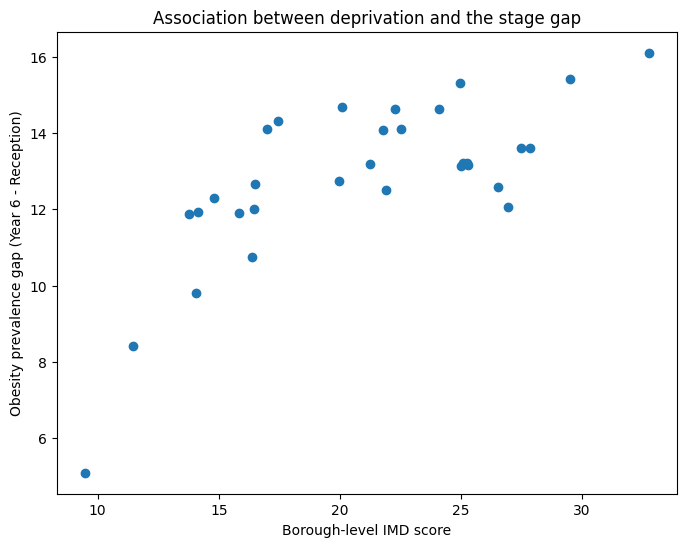

Correlation: IMD score vs stage gap


,imd_score,gap_y6_minus_reception
imd_score,1.000000,0.715558
gap_y6_minus_reception,0.715558,1.000000


In [13]:

# 2018 Year 6 obesity + deprivation
year6_dep = year6_map.merge(borough_dep, on="borough", how="left")

plt.figure(figsize=(8, 6))
plt.scatter(year6_dep["imd_score"], year6_dep["obesity_prevalence"])
plt.xlabel("Borough-level IMD score")
plt.ylabel("Year 6 obesity prevalence (2018/19)")
plt.title("Association between deprivation and Year 6 obesity prevalence")
plt.show()

print("Correlation: IMD score vs Year 6 obesity prevalence")
display(year6_dep[["imd_score", "obesity_prevalence"]].corr())

# 2018 gap + deprivation
gap_dep = gap_df_2018.merge(borough_dep, on="borough", how="left")

plt.figure(figsize=(8, 6))
plt.scatter(gap_dep["imd_score"], gap_dep["gap_y6_minus_reception"])
plt.xlabel("Borough-level IMD score")
plt.ylabel("Obesity prevalence gap (Year 6 - Reception)")
plt.title("Association between deprivation and the stage gap")
plt.show()

print("Correlation: IMD score vs stage gap")
display(gap_dep[["imd_score", "gap_y6_minus_reception"]].corr())


Supplementary Regression Tree Test R²: 0.945
Supplementary Regression Tree Test RMSE: 1.449


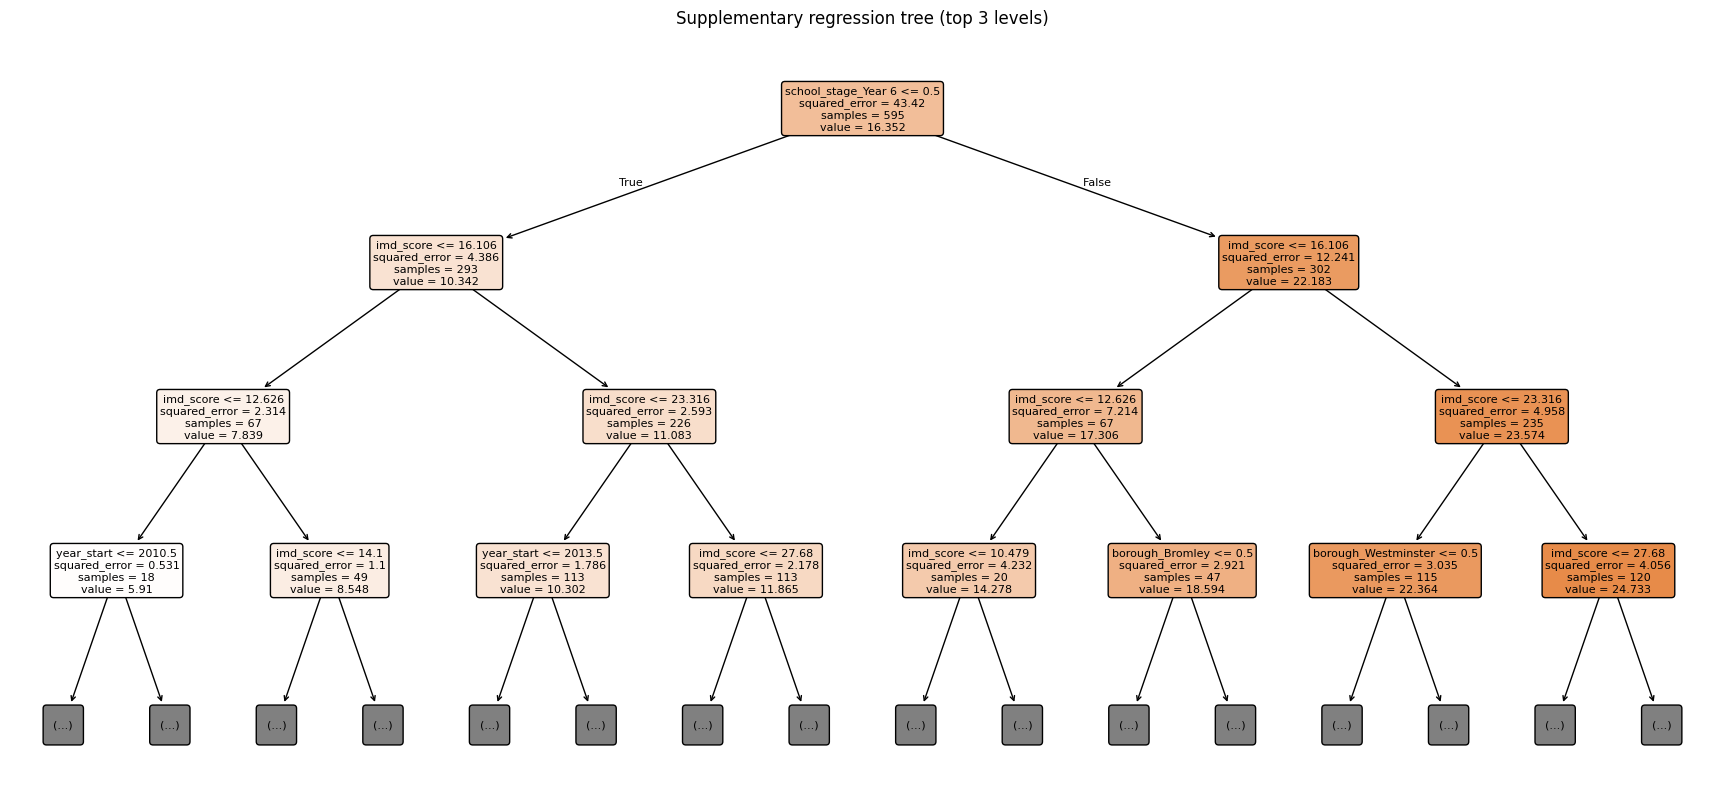

In [14]:
# =========================
# Supplementary regression tree model
# =========================

model_df = obesity_model_long_enhanced[
    ["borough", "school_stage", "year_start", "imd_score", "obesity_prevalence"]
].dropna().copy()

tree_X = pd.get_dummies(
    model_df[["borough", "school_stage", "year_start", "imd_score"]],
    columns=["borough", "school_stage"],
    drop_first=True
)
tree_y = model_df["obesity_prevalence"].astype(float)

tree_X_train, tree_X_test, tree_y_train, tree_y_test = train_test_split(
    tree_X, tree_y, test_size=0.2, random_state=42
)

tree_model = DecisionTreeRegressor(
    max_depth=4,
    min_samples_leaf=4,
    random_state=42
)
tree_model.fit(tree_X_train, tree_y_train)

tree_pred = tree_model.predict(tree_X_test)

tree_r2 = r2_score(tree_y_test, tree_pred)
tree_rmse = np.sqrt(mean_squared_error(tree_y_test, tree_pred))

print(f"Supplementary Regression Tree Test R²: {tree_r2:.3f}")
print(f"Supplementary Regression Tree Test RMSE: {tree_rmse:.3f}")

plt.figure(figsize=(22, 10))
plot_tree(
    tree_model,
    feature_names=tree_X.columns,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)
plt.title("Supplementary regression tree (top 3 levels)")
plt.show()

Supplementary RF Test R²: 0.972
Supplementary RF Test RMSE: 1.032


,feature,importance
0,school_stage_Year 6,0.812315
1,imd_score,0.150914
2,year_start,0.015299
3,borough_Richmond upon Thames,0.003489
4,borough_Southwark,0.003168
5,borough_Westminster,0.001786
6,borough_Wandsworth,0.001362
7,borough_Kensington and Chelsea,0.001127
8,borough_Waltham Forest,0.000999
9,borough_Sutton,0.000832


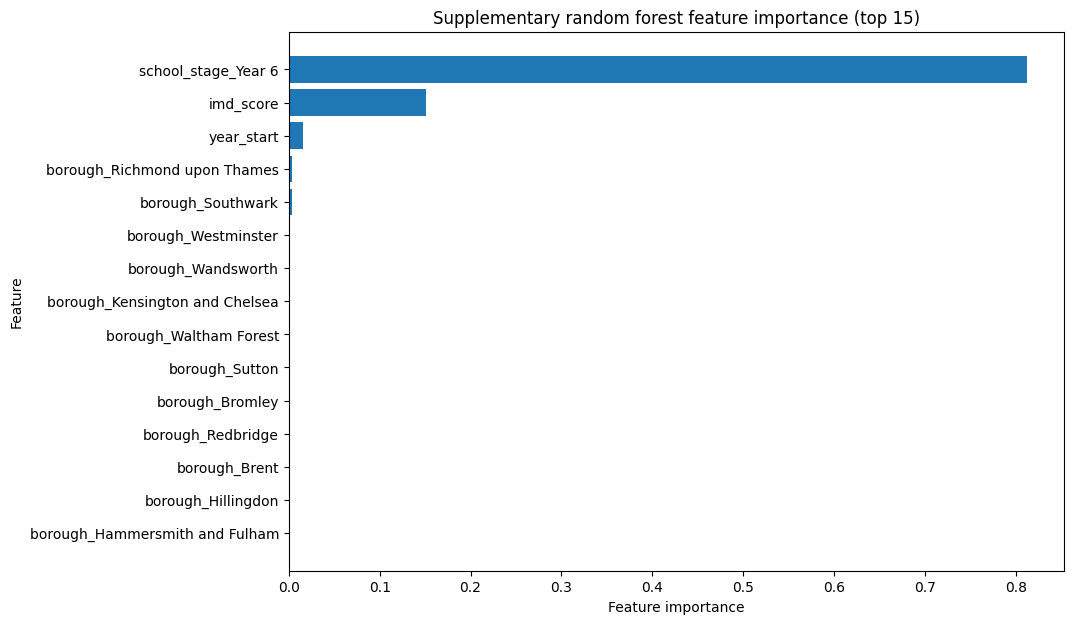

In [15]:

# =========================
# Supplementary random forest model
# =========================

model_df = obesity_model_long_enhanced[
    ["borough", "school_stage", "year_start", "imd_score", "obesity_prevalence"]
].dropna().copy()

rf_X = pd.get_dummies(
    model_df[["borough", "school_stage", "year_start", "imd_score"]],
    columns=["borough", "school_stage"],
    drop_first=True
)
rf_y = model_df["obesity_prevalence"].astype(float)

rf_X_train, rf_X_test, rf_y_train, rf_y_test = train_test_split(
    rf_X, rf_y, test_size=0.2, random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42
)
rf_model.fit(rf_X_train, rf_y_train)

rf_pred = rf_model.predict(rf_X_test)

rf_r2 = r2_score(rf_y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(rf_y_test, rf_pred))

print(f"Supplementary RF Test R²: {rf_r2:.3f}")
print(f"Supplementary RF Test RMSE: {rf_rmse:.3f}")

importance_df = pd.DataFrame({
    "feature": rf_X.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df.head(15).reset_index(drop=True))

top15 = importance_df.head(15).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top15["feature"], top15["importance"])
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Supplementary random forest feature importance (top 15)")
plt.show()


,feature,importance_mean,importance_std
0,school_stage_Year 6,1.691913,0.150733
1,imd_score,0.321572,0.028476
2,year_start,0.021558,0.003765
3,borough_Southwark,0.005123,0.001429
4,borough_Kensington and Chelsea,0.003587,0.000958
5,borough_Wandsworth,0.002596,0.000689
6,borough_Richmond upon Thames,0.002268,0.000900
7,borough_Hillingdon,0.001392,0.000289
8,borough_Waltham Forest,0.001292,0.000314
9,borough_Westminster,0.001266,0.001059


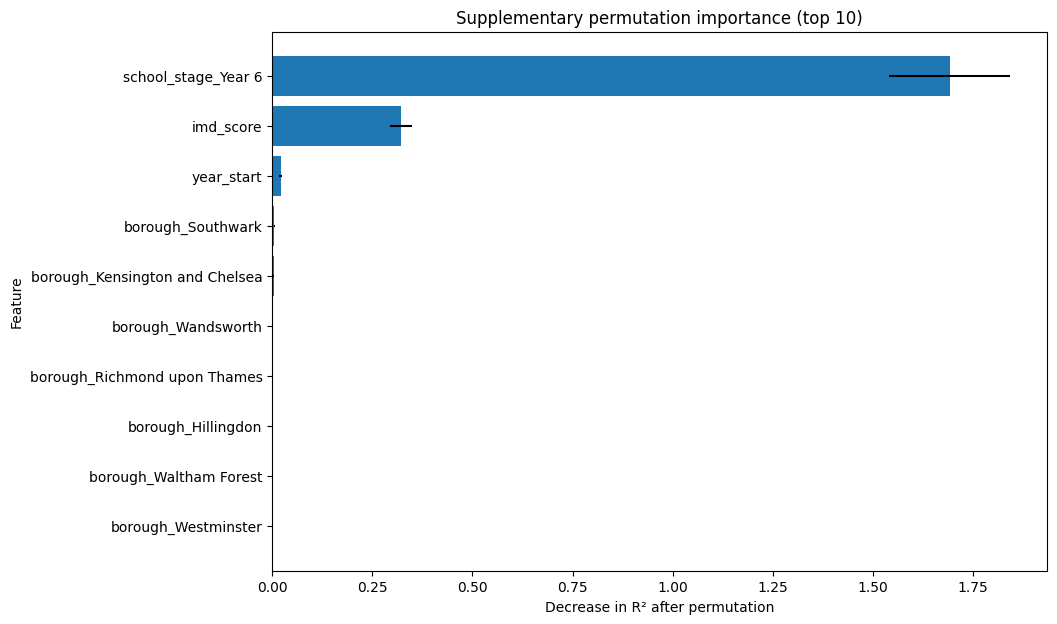

In [16]:

# =========================
# Supplementary permutation importance
# =========================

perm_result = permutation_importance(
    estimator=rf_model,
    X=rf_X_test,
    y=rf_y_test,
    n_repeats=20,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": rf_X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

display(perm_df.head(15).reset_index(drop=True))

top10_perm = perm_df.head(10).sort_values("importance_mean", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top10_perm["feature"], top10_perm["importance_mean"], xerr=top10_perm["importance_std"])
plt.xlabel("Decrease in R² after permutation")
plt.ylabel("Feature")
plt.title("Supplementary permutation importance (top 10)")
plt.show()



## Results and discussion

[[ go back to the top ]](#Table-of-contents)


### 5.1 Spatial variation and stage differences
The results of the 2018/19 academic year show that there are obvious spatial differences in childhood obesity prevalence across London boroughs.
The average obesity prevalence in Reception is 9.83%, and in Year 6 it is 22.64%, with significant differences between school stages.
In all 31 boroughs, prevalence in Year 6 is higher than in Reception, and the average borough-level difference is 12.81 percentage points. This shows that the stage differences are systematic, not only in a few areas.
The ranking of each borough also reflects significant inequality.
In the 2018/19 academic year, the boroughs with the highest Year 6 obesity prevalence are: Barking and Dagenham, Newham, Enfield, Greenwich and Brent;
The lowest are: Richmond upon Thames, Kingston upon Thames, Bromley, Wandsworth, Merton.
The map results further confirm this pattern: high-prevalence boroughs are unevenly distributed in London.
In general, the above results show that childhood obesity in London has significant spatial structural characteristics.
### 5.2 Gap patterns over space and time
The analysis of school-stage differences adds an important spatial dimension to the research. Although the obesity rate of Year 6 pupils in all regions is higher than that of Reception children, the magnitude of the difference varies across boroughs.
In the 2018/19 academic year, the boroughs with the largest obesity rate gaps are Barking and Dagenham, Newham, Enfield, Westminster, and Kensington and Chelsea; the smallest gaps are in Richmond upon Thames, Kingston upon Thames, Bromley, Havering, and Sutton.
This shows that the inequality between boroughs is not only reflected in the absolute level of obesity rate, but also in the increase in obesity rate from the start to the end of primary school.
This gap also shows persistence over time. During the whole study period, the average annual gap was 11.69 percentage points, ranging from 10.01 to 13.20 percentage points. This shows that the obesity rate gap between Reception and Year 6 is a stable feature in the data.
### 5.3 Deprivation and supplementary modelling
Poverty analysis shows that socio-economic background may explain some of the inequality. The borough-level IMD score is positively correlated with Year 6 obesity prevalence (correlation coefficient ≈ 0.83), and is also positively correlated with the obesity rate gap between Year 6 and Reception (correlation coefficient ≈ 0.72).
This means that boroughs with higher deprivation tend to have higher obesity rates and larger school-stage gaps. However, the results need to be interpreted carefully, because the deprivation indicator is treated as a time-invariant background variable, rather than a year-specific measure.
The supplementary tree model results generally support the descriptive analysis conclusions. The test-set R² of the regression tree is 0.945; the random forest performs slightly better, with a test-set R² of 0.972. Feature importance shows that school stage is the strongest predictor, IMD score provides additional explanatory power, and the influence of year is relatively weak.



## Conclusion

[[ go back to the top ]](#Table-of-contents)

This study shows that childhood obesity in London exhibits significant spatial inequality at the borough level.
In the 2018/19 academic year, in all 31 boroughs, the prevalence of obesity in Year 6 was consistently higher than in Reception, and the gap between the two school stages was large and unevenly distributed across space.
At the same time, the results show that boroughs with a higher level of deprivation tend to have a higher prevalence of obesity and a larger stage gap, although this study regards deprivation as a static background indicator rather than a year-specific measure.
The supplementary tree-based model analysis confirms the important role of school stage and borough context.



## References

[[ go back to the top ]](#Table-of-contents)

Breiman, L. (2001). Random forests. *Machine Learning, 45*(1), 5–32. https://doi.org/10.1023/A:1010933404324

Breiman, L., Friedman, J. H., Olshen, R. A., & Stone, C. J. (1984). *Classification and regression trees*. Taylor & Francis.

NHS Digital. (2023, October 19). *National Child Measurement Programme, England, 2022/23 school year*. https://www.gov.uk/government/statistics/national-child-measurement-programme-england-202223-school-year

Office for Health Improvement and Disparities. (2023, November 7). *Obesity profile: Statistical commentary November 2023*. https://www.gov.uk/government/statistics/obesity-profile-november-2023-update/obesity-profile-statistical-commentary-november-2023


World Health Organization. (2025, December 8). *Obesity and overweight*. https://www.who.int/news-room/fact-sheets/detail/obesity-and-overweight
